# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Nayla Poetri Kurnia
- **Email:** cdcc200d6x2356@student.devacademy.id
- **ID Dicoding:** CDCC200D6X2356

## Latar Belakang
Dataset ini digunakan untuk menganalisis pola penggunaan sepeda berdasarkan faktor cuaca, musim, dan suhu.

## Tujuan Analisis
- Mengetahui pengaruh suhu terhadap jumlah penyewaan
- Mengidentifikasi pola penggunaan berdasarkan musim
- Melihat tren penggunaan dari waktu ke waktu

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 :  Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda?
- Pertanyaan 2 : Bagaimana pola penyewaan sepeda berdasarkan musim?
- Pertanyaan 3 : Bagaimana distribusi tingkat penyewaan sepeda?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

Pada tahap ini dilakukan proses pengambilan data dari file CSV yang berisi informasi penyewaan sepeda harian.

In [ ]:
df = pd.read_csv("day.csv")
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Dataset memuat berbagai fitur yang mencakup informasi waktu, kondisi cuaca, serta jumlah penyewaan sepeda.
- Terdapat dua tipe pengguna, yaitu casual dan registered, yang membentuk total penyewaan `cnt`.
- Variabel seperti season, weathersit, dan workingday menunjukkan bahwa data memiliki informasi kategori terkait kondisi lingkungan dan waktu.
- Data juga mencakup variabel numerik seperti suhu `temp`, kelembaban `hum`, dan kecepatan angin `windspeed` yang dapat digunakan untuk analisis lebih lanjut.

### Assessing Data

Tahap ini dilakukan untuk memahami struktur dataset, tipe data, serta memeriksa adanya missing values dan data duplicate. Hal ini penting untuk memastikan kualitas data sebelum dilakukan analisis lebih lanjut.

In [ ]:
# cek struktur data
df.info()

# statistik deskriptif
df.describe()

# cek missing value
df.isnull().sum()

# cek duplicate
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


np.int64(0)

**Insight:**
- Dataset terdiri dari 731 data dengan 16 fitur yang mencakup informasi waktu, kondisi cuaca, serta jumlah penyewaan sepeda, sehingga cukup representatif untuk analisis pola penggunaan.
- Tidak terdapat missing value maupun data duplikat, sehingga kualitas data dapat dianggap baik dan siap digunakan untuk analisis lebih lanjut.
- Sebagian besar variabel bertipe numerik, yang memungkinkan analisis kuantitatif seperti tren dan perbandingan antar variabel.
- Variabel seperti cuaca `weathersit`, suhu `temp`, dan hari kerja `workingday` berpotensi memiliki pengaruh terhadap jumlah penyewaan sepeda.
- Kolom tanggal `dteday` perlu dikonversi ke format datetime agar dapat digunakan dalam analisis berbasis waktu seperti tren bulanan atau harian.

### Cleaning Data

Tahap ini bertujuan untuk memastikan data siap dianalisis dengan:
- Mengubah tipe data tanggal
- Mengubah label kategori agar lebih mudah dipahami

In [ ]:
# Ubah tipe data tanggal
df["dteday"] = pd.to_datetime(df["dteday"])

# Mapping kategori season
season_map = {
    1: "Spring",
    2: "Summer",
    3: "Fall",
    4: "Winter"
}
df["season"] = df["season"].map(season_map)

# Mapping kategori cuaca
weather_map = {
    1: "Clear",
    2: "Mist",
    3: "Light Rain/Snow",
    4: "Heavy Rain/Snow"
}
df["weathersit"] = df["weathersit"].map(weather_map)

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    object        
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    object        
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

**Insight:**
- Kolom `dteday` telah dikonversi ke format datetime, sehingga memungkinkan analisis berbasis waktu seperti tren bulanan dan harian.
- Variabel kategorikal seperti `season` dan `weathersit` telah diubah menjadi label yang lebih deskriptif, sehingga mempermudah interpretasi hasil visualisasi dan analisis.
- Tidak terdapat perubahan jumlah data selama proses cleaning, menunjukkan bahwa tidak ada data yang hilang atau terhapus.
- Proses cleaning ini meningkatkan keterbacaan dan kualitas dataset, sehingga siap digunakan untuk analisis eksploratif dan pembuatan visualisasi yang lebih informatif.
- Dengan format data yang sudah rapi, analisis selanjutnya dapat difokuskan pada hubungan antar variabel seperti pengaruh cuaca dan musim terhadap jumlah penyewaan sepeda.

## Exploratory Data Analysis (EDA)

Tahap ini dilakukan untuk memahami pola dan hubungan antar variabel dalam dataset sebelum dilakukan visualisasi lebih lanjut.

In [ ]:
df.describe()

,instant,dteday,yr,mnth,holiday,weekday,workingday,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,0.500684,6.519836,0.028728,2.997264,0.683995,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,0.000000,4.000000,0.000000,1.000000,0.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,1.000000,7.000000,0.000000,3.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,1.000000,10.000000,0.000000,5.000000,1.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,1.000000,12.000000,1.000000,6.000000,1.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,0.500342,3.451913,0.167155,2.004787,0.465233,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


### Explore ...

In [ ]:
# Analisis rata-rata penggunaan berdasarkan musim
df.groupby("season")["cnt"].mean()

,cnt
season,
Fall,5644.303191
Spring,2604.132597
Summer,4992.331522
Winter,4728.162921


In [ ]:
# Analisis rata-rata penggunaan berdasarkan kondisi cuaca
df.groupby("weathersit")["cnt"].mean()

,cnt
weathersit,
Clear,4876.786177
Light Rain/Snow,1803.285714
Mist,4035.862348


In [ ]:
# Analisis penggunaan berdasarkan hari kerja vs hari libur
df.groupby("workingday")["cnt"].mean()

,cnt
workingday,
0,4330.168831
1,4584.820000


In [ ]:
# Analisis penggunaan berdasarkan hari dalam seminggu
df.groupby("weekday")["cnt"].mean()

,cnt
weekday,
0,4228.828571
1,4338.123810
2,4510.663462
3,4548.538462
4,4667.259615
5,4690.288462
6,4550.542857


In [ ]:
monthly = df.resample("M", on="dteday")["cnt"].sum()
monthly.head()

/tmp/ipykernel_1255/964509272.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.resample("M", on="dteday")["cnt"].sum()


,cnt
dteday,
2011-01-31,38189
2011-02-28,48215
2011-03-31,64045
2011-04-30,94870
2011-05-31,135821


**Insight:**
- Penyewaan sepeda menunjukkan variasi berdasarkan musim, dengan musim Fall memiliki rata-rata penyewaan tertinggi, sedangkan Spring terendah.
- Kondisi cuaca sangat mempengaruhi jumlah penyewaan, dimana cuaca cerah menghasilkan penyewaan tertinggi, sedangkan kondisi hujan/salju menurunkan jumlah penyewaan secara signifikan.
- Terdapat perbedaan pola penggunaan antara hari kerja dan hari libur, dimana hari kerja cenderung memiliki jumlah penyewaan yang sedikit lebih tinggi.
- Berdasarkan hari dalam seminggu, penyewaan relatif stabil namun terdapat peningkatan pada beberapa hari tertentu, yang mengindikasikan adanya pola perilaku pengguna.
- Analisis tren bulanan menunjukkan adanya peningkatan penyewaan dari awal tahun hingga pertengahan tahun, yang mengindikasikan pola musiman dalam penggunaan sepeda.

## Visualization & Explanatory Analysis

Visualisasi digunakan untuk menjawab pertanyaan bisnis yang telah dirumuskan sebelumnya.

### Pertanyaan 1: Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda?

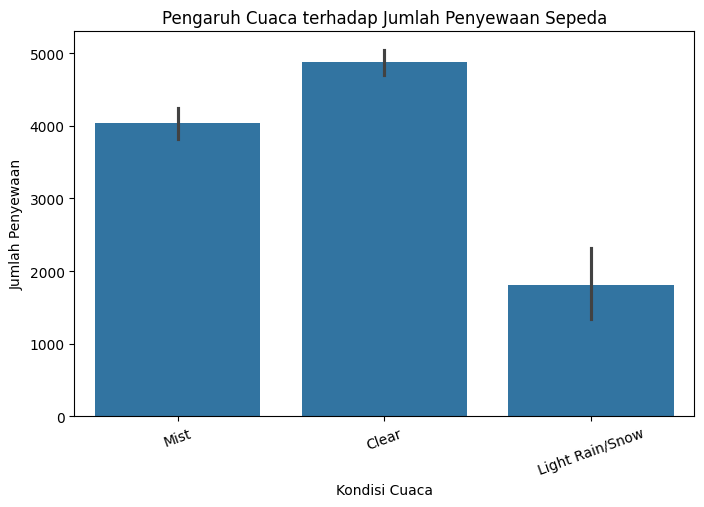

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x="weathersit", y="cnt", data=df)

plt.title("Pengaruh Cuaca terhadap Jumlah Penyewaan Sepeda")
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Jumlah Penyewaan")
plt.xticks(rotation=20)

plt.show()

**Insight:**
- Kondisi cuaca cerah `Clear` menghasilkan jumlah penyewaan sepeda tertinggi.
- Cuaca berkabut `Mist` masih menunjukkan tingkat penyewaan yang cukup tinggi, namun lebih rendah dibandingkan cuaca cerah.
- Kondisi hujan atau salju `Light Rain/Snow` menyebabkan penurunan signifikan pada jumlah penyewaan.
- Hal ini menunjukkan bahwa kondisi cuaca merupakan faktor penting yang mempengaruhi keputusan pengguna dalam menyewa sepeda.

### Pertanyaan 2: Bagaimana pola penyewaan sepeda berdasarkan musim?

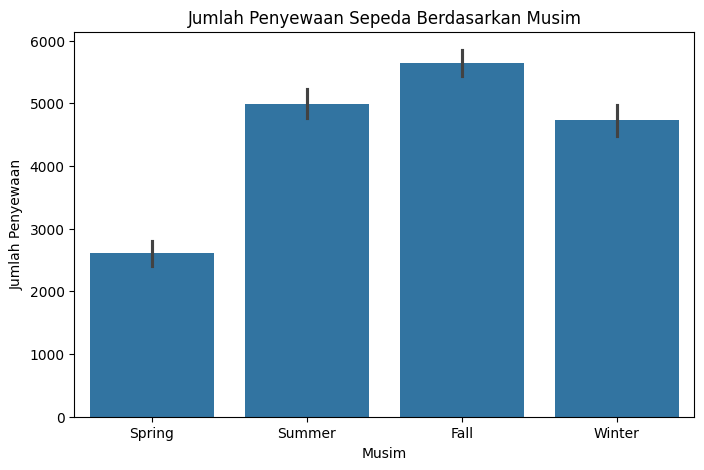

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x="season", y="cnt", data=df)

plt.title("Jumlah Penyewaan Sepeda Berdasarkan Musim")
plt.xlabel("Musim")
plt.ylabel("Jumlah Penyewaan")

plt.show()

**Insight:**
- Musim `Fall` memiliki jumlah penyewaan sepeda tertinggi dibandingkan musim lainnya.
- Musim `Summer` dan `Winter` juga menunjukkan tingkat penyewaan yang relatif tinggi.
- Musim `Spring` memiliki jumlah penyewaan terendah.
- Hal ini menunjukkan adanya pola musiman, dimana kondisi lingkungan pada musim tertentu lebih mendukung aktivitas bersepeda.

## Analisis Lanjutan (Opsional)

### Pertanyaan 3: Bagaimana distribusi tingkat penyewaan sepeda?

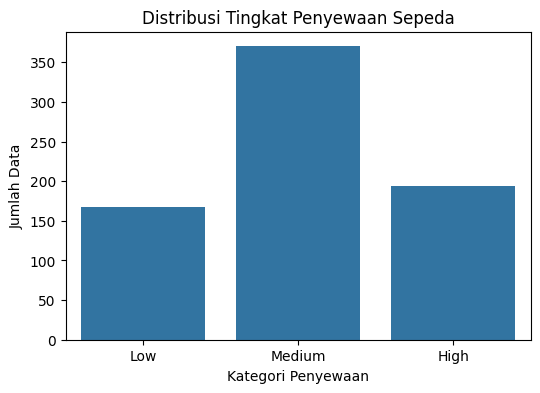

In [ ]:
# Binning
df["kategori_sewa"] = pd.cut(
    df["cnt"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

plt.figure(figsize=(6,4))
sns.countplot(x="kategori_sewa", data=df)

plt.title("Distribusi Tingkat Penyewaan Sepeda")
plt.xlabel("Kategori Penyewaan")
plt.ylabel("Jumlah Data")

plt.show()

**Insight:**
- Sebagian besar data berada pada kategori penyewaan Medium, menunjukkan bahwa penggunaan sepeda cenderung stabil dalam tingkat sedang.
- Kategori High menunjukkan adanya periode tertentu dengan lonjakan permintaan yang signifikan.
- Kategori Low menggambarkan kondisi dimana aktivitas penyewaan relatif rendah.
- Distribusi ini menunjukkan bahwa meskipun penggunaan sepeda cenderung konsisten, terdapat variasi yang dipengaruhi oleh faktor eksternal seperti cuaca dan musim.

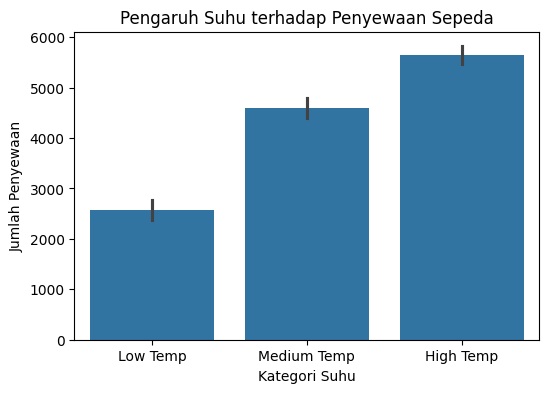

In [ ]:
df["temp_group"] = pd.cut(
    df["temp"],
    bins=3,
    labels=["Low Temp", "Medium Temp", "High Temp"]
)

plt.figure(figsize=(6,4))
sns.barplot(x="temp_group", y="cnt", data=df)

plt.title("Pengaruh Suhu terhadap Penyewaan Sepeda")
plt.xlabel("Kategori Suhu")
plt.ylabel("Jumlah Penyewaan")

plt.show()

**Insight**
- Penyewaan sepeda meningkat seiring dengan kenaikan suhu.
- Kategori High Temp memiliki jumlah penyewaan tertinggi dibanding kategori lainnya.
- Suhu rendah menunjukkan jumlah penyewaan yang lebih sedikit.
- Hal ini menunjukkan bahwa kenyamanan suhu berpengaruh terhadap minat pengguna dalam bersepeda.

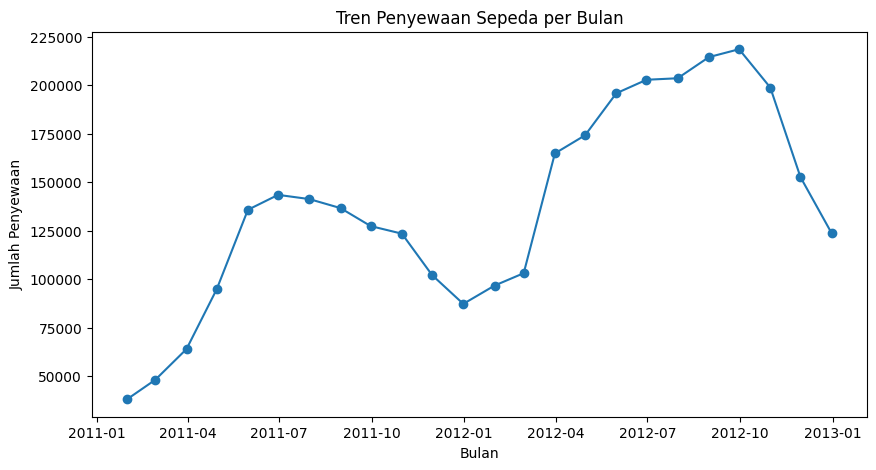

In [ ]:
monthly = df.resample("ME", on="dteday")["cnt"].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly.index, monthly.values, marker='o')

plt.title("Tren Penyewaan Sepeda per Bulan")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Penyewaan")

plt.show()

**Insight**
- Terdapat pola musiman dalam penyewaan sepeda, dimana jumlah penyewaan meningkat dari awal tahun hingga pertengahan tahun.
- Puncak penyewaan terjadi pada pertengahan hingga akhir tahun.
- Setelah mencapai puncak, terjadi penurunan jumlah penyewaan menuju akhir tahun.
- Pola ini menunjukkan bahwa faktor musim dan kondisi lingkungan mempengaruhi tingkat penggunaan sepeda.

## Conclusion

**Conclusion**

1. Pengaruh Cuaca terhadap Penyewaan Sepeda  
Kondisi cuaca memiliki pengaruh signifikan terhadap jumlah penyewaan sepeda. Penyewaan tertinggi terjadi pada kondisi cuaca cerah (Clear), sedangkan kondisi cuaca buruk seperti hujan atau salju menyebabkan penurunan jumlah penyewaan. Hal ini menunjukkan bahwa semakin baik kondisi cuaca, semakin tinggi minat pengguna untuk bersepeda.

2. Pola Penyewaan Berdasarkan Musim  
Penyewaan sepeda menunjukkan pola musiman, dimana musim Fall memiliki jumlah penyewaan tertinggi dan musim Spring terendah. Musim dengan kondisi lingkungan yang lebih nyaman cenderung meningkatkan aktivitas penggunaan sepeda.

3. Distribusi Tingkat Penyewaan  
Sebagian besar penyewaan berada pada kategori Medium, yang menunjukkan bahwa penggunaan sepeda relatif stabil. Namun, terdapat kategori High yang menunjukkan lonjakan permintaan pada waktu tertentu, serta kategori Low yang menggambarkan kondisi dengan aktivitas rendah. Hal ini menunjukkan adanya variasi penggunaan yang dipengaruhi oleh faktor eksternal seperti cuaca dan suhu.

In [ ]:
df.to_csv('day_clean.csv', index=False)

In [ ]:
from google.colab import files
files.download('day_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>